<a href="https://colab.research.google.com/github/Tatsuki711/lineEchoBot/blob/master/openpose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pose Detection with OpenPose

This notebook uses an open source project [CMU-Perceptual-Computing-Lab/openpose](https://github.com/CMU-Perceptual-Computing-Lab/openpose.git) to detect/track multi person poses on a given video.

Please read the [OpenPose license](https://github.com/CMU-Perceptual-Computing-Lab/openpose/blob/master/LICENSE) before running this script.


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
OPENPOSE_PATH="./openpose/"
HOME_PATH='./'

In [17]:
!echo $HOME_PATH

./


##Install OpenPose

In [18]:
#@title
!pip install ffmpeg-python
from os.path import exists, join, basename, splitext

def show_local_mp4_video(file_name, width=640, height=480):
  import io
  import base64
  from IPython.display import HTML
  video_encoded = base64.b64encode(io.open(file_name, 'rb').read())
  return HTML(data='''<video width="{0}" height="{1}" alt="test" controls>
                        <source src="data:video/mp4;base64,{2}" type="video/mp4" />
                      </video>'''.format(width, height, video_encoded.decode('ascii')))


# see: https://github.com/CMU-Perceptual-Computing-Lab/openpose/issues/949
# install new CMake becaue of CUDA10
!wget -q https://cmake.org/files/v3.17/cmake-3.17.2-Linux-x86_64.tar.gz
!tar xfz cmake-3.17.2-Linux-x86_64.tar.gz --strip-components=1 -C /usr/local

# install system dependencies
!apt-get -qq install -y libatlas-base-dev libprotobuf-dev libleveldb-dev libsnappy-dev libhdf5-serial-dev protobuf-compiler libgflags-dev libgoogle-glog-dev liblmdb-dev opencl-headers ocl-icd-opencl-dev libviennacl-dev

git_repo_url = 'https://github.com/CMU-Perceptual-Computing-Lab/openpose.git'
project_name = splitext(basename(git_repo_url))[0]
!rm -rf openpose
# clone openpose
!git clone -q --depth 1 $git_repo_url
# --recursive necessary in the line below, as otherwise you can (sometimes) get "lpthreads" errors in cmake ("undefined reference to `pthread_create'" etc). See, for example, https://github.com/facebookarchive/caffe2/issues/1234
!sed -i 's/execute_process(COMMAND git checkout --recursive master WORKING_DIRECTORY ${CMAKE_SOURCE_DIR}\/3rdparty\/caffe)/execute_process(COMMAND git checkout f019d0dfe86f49d1140961f8c7dec22130c83154 WORKING_DIRECTORY ${CMAKE_SOURCE_DIR}\/3rdparty\/caffe)/g' openpose/CMakeLists.txt
!cd openpose && git submodule update --init --recursive --remote

Submodule '3rdparty/caffe' (https://github.com/CMU-Perceptual-Computing-Lab/caffe.git) registered for path '3rdparty/caffe'
Submodule '3rdparty/pybind11' (https://github.com/pybind/pybind11.git) registered for path '3rdparty/pybind11'
Cloning into '/content/openpose/3rdparty/caffe'...
Cloning into '/content/openpose/3rdparty/pybind11'...
Submodule path '3rdparty/caffe': checked out '2d4bf549aabf97265f76b9599b82540dde9218ed'
Submodule path '3rdparty/pybind11': checked out '945e251a6ce7273058b36214d94415e9c9530b8e'


Workaround for server problem (run if you see `file DOWNLOAD HASH mismatch` when building OpenPose):

In [22]:
!cp "/content/drive/MyDrive/models.zip" /content

In [23]:
#@title
# Workaround for server connection problem ("file DOWNLOAD HASH mismatch"),see, e.g.,
# https://github.com/CMU-Perceptual-Computing-Lab/openpose/issues/1602#issuecomment-641653411
!apt-get install unzip

# !wget -O models.zip  --no-check-certificate -r 'https://drive.google.com/uc?id=1QCSxJZpnWvM00hx49CJ2zky7PWGzpcEh&export=download'
!unzip -o models.zip -d openpose

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Archive:  models.zip
 extracting: openpose/models/pose/coco/pose_iter_440000.caffemodel  
 extracting: openpose/models/pose/coco/main.html  
 extracting: openpose/models/pose/mpi/pose_iter_160000.caffemodel  
 extracting: openpose/models/pose/body_25/pose_iter_584000.caffemodel  
 extracting: openpose/models/pose/body_25/training_results_source.txt  
 extracting: openpose/models/pose/body_25/training_log.txt  
   creating: openpose/models/pose/body_21a_video/
 extracting: openpose/models/pose/body_21a_video/pose_deploy.prototxt  
 extracting: openpose/models/pose/body_21a_video/pose_iter_264000.caffemodel  
   creating: openpose/models/pose/1_25BSuperModel11FullVGG/
   creating: openpose/models/pose/1_25BSuperModel11FullVGG/body_25b/
 extracting: openpose/models/pose/1_25BS

In [24]:
# use 'sed' to comment out the line in the OpenPose repo that downloads the model from the failed link
! sed -i 's/executeShInItsFolder "getModels.sh"/# executeShInItsFolder "getModels.sh"/g' ./openpose/scripts/ubuntu/install_openpose_JetsonTX2_JetPack3.1.sh
! sed -i 's/executeShInItsFolder "getModels.sh"/# executeShInItsFolder "getModels.sh"/g' ./openpose/scripts/ubuntu/install_openpose_JetsonTX2_JetPack3.3.sh
! sed -i 's/download_model("BODY_25"/# download_model("BODY_25"/g' ./openpose/CMakeLists.txt
! sed -i 's/78287B57CF85FA89C03F1393D368E5B7/# 78287B57CF85FA89C03F1393D368E5B7/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("body (COCO)"/# download_model("body (COCO)"/g' ./openpose/CMakeLists.txt
! sed -i 's/5156d31f670511fce9b4e28b403f2939/# 5156d31f670511fce9b4e28b403f2939/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("body (MPI)"/# download_model("body (MPI)"/g' ./openpose/CMakeLists.txt
! sed -i 's/2ca0990c7562bd7ae03f3f54afa96e00/# 2ca0990c7562bd7ae03f3f54afa96e00/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("face"/# download_model("face"/g' ./openpose/CMakeLists.txt
! sed -i 's/e747180d728fa4e4418c465828384333/# e747180d728fa4e4418c465828384333/g' ./openpose/CMakeLists.txt
! sed -i 's/download_model("hand"/# download_model("hand"/g' ./openpose/CMakeLists.txt
! sed -i 's/a82cfc3fea7c62f159e11bd3674c1531/# a82cfc3fea7c62f159e11bd3674c1531/g' ./openpose/CMakeLists.txt

In [ ]:
! ls -lha /usr/lib/x86_64-linux-gnu

In [25]:
# build openpose
# CUDA
# !cd openpose && rm -rf build || true && mkdir build && cd build && cmake .. -DUSE_CUDNN=OFF && make -j`nproc`
#!cd openpose && rm -rf build || true && mkdir build && cd build && cmake .. && make -j`nproc`
# CPU
# !cd openpose && rm -rf build || true && mkdir build && cd build && cmake -DGPU_MODE=CPU_ONLY -DUSE_MKL=OFF .. && cmake --build . --config Release && make -j`nproc`

!cd openpose && rm -rf build || true && mkdir build

In [26]:
cmake_file='/content/openpose/CMakeLists.txt'
!cd openpose && sed -i 's/-DBUILD_python=OFF/-DBUILD_python=ON/g' $cmake_file
!cd openpose && sed -i 's/-DBUILD_python_layer=OFF/-DBUILD_python_layer=ON/g' $cmake_file

!cd openpose && sed -i 's/option(BUILD_PYTHON "Build OpenPose python." OFF)/option(BUILD_PYTHON "OpenPose python." ON)\noption(BUILD_BIN_FOLDER "Copy 3rd-party DLL files." ON)/g' $cmake_file

In [27]:
# CUDA
!cd openpose && cd build && cmake .. -DUSE_CUDNN=OFF -DGENERATE_PYTHON_BINDINGS:BOOL="1" -DPYTHON_LIBRARY='/usr/lib/x86_64-linux-gnu/libpython3.10.so' && make -j`nproc`

 # CPU
# !cd openpose && cd build && cmake .. -DGPU_MODE=CPU_ONLY -DUSE_MKL=OFF -DGENERATE_PYTHON_BINDINGS:BOOL="1" -DPYTHON_LIBRARY='/usr/lib/x86_64-linux-gnu/libpython3.10.so'
# !cd openpose && cd build && make -j`nproc`

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Check for working C compiler: /usr/bin/cc
-- Check for working C compiler: /usr/bin/cc - works
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Detecting C compile features
-- Detecting C compile features - done
-- Check for working CXX compiler: /usr/bin/c++
-- Check for working CXX compiler: /usr/bin/c++ - works
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- GCC detected, adding compile flags
-- GCC detected, adding compile flags
-- Looking for pthread.h
-- Looking for pthread.h - found
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Found CUDA: /usr/local/cuda (found version "12.2") 
-- Building with CUDA.
-- CUDA detected: 12.2
-- Added CUDA NVCC flags for: sm_75
-- Found cuDNN

## Try on YouTube video

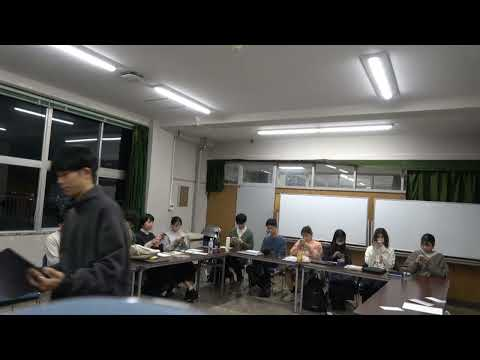

In [1]:
from IPython.display import YouTubeVideo
YOUTUBE_ID = 'Vb3QbGNUeh8'
YouTubeVideo(YOUTUBE_ID)

Download the above youtube video, cut and do the pose detection on that section:

In [7]:
# ! sudo -H pip install --upgrade youtube-dl
! pip install --upgrade --force-reinstall "git+https://github.com/ytdl-org/youtube-dl.git"

  Cloning https://github.com/ytdl-org/youtube-dl.git to /tmp/pip-req-build-f3ed3apw
  Running command git clone --filter=blob:none --quiet https://github.com/ytdl-org/youtube-dl.git /tmp/pip-req-build-f3ed3apw
  Resolved https://github.com/ytdl-org/youtube-dl.git to commit 1036478d130c5f2001eca2d7d12558abe601d933
  Preparing metadata (setup.py) ... done
  Created wheel for youtube_dl: filename=youtube_dl-2021.12.17-py2.py3-none-any.whl size=1972720 sha256=b414b277ae7142e7c3cc2f598f07da9360940a357b67e731d3fffa16d42fdaa2
  Stored in directory: /tmp/pip-ephem-wheel-cache-zxvmkm3d/wheels/64/8e/40/866e846163e3e4859bbe820ff8847ec97f4320864f1525aa9a
Successfully built youtube_dl
  Attempting uninstall: youtube_dl
    Found existing installation: youtube_dl 2021.12.17
    Uninstalling youtube_dl-2021.12.17:
      Successfully uninstalled youtube_dl-2021.12.17


In [8]:
!rm -rf youtube.mp4
# download the youtube with the given ID
!youtube-dl -f 'bestvideo[ext=mp4]' --output "youtube.%(ext)s" https://www.youtube.com/watch?v=$YOUTUBE_ID
# cut the video
!ffmpeg -y -loglevel info -i youtube.mp4 -ss 10 -t 7 video.mp4

[youtube] Vb3QbGNUeh8: Downloading webpage
[youtube] Vb3QbGNUeh8: Downloading API JSON
[dashsegments] Total fragments: 13
[download] Destination: youtube.mp4
[download] 100% of 125.11MiB in 00:25
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable

In [10]:
# detect poses on the these 5 seconds
!cd $OPENPOSE_PATH && rm ../openpose.avi
!cd $OPENPOSE_PATH && chmod -R 755 './build/'
!cd $OPENPOSE_PATH && ./build/examples/openpose/openpose.bin --video ../video.mp4 --write_json ./output/ --display 0  --write_video ../openpose.avi --face
# convert the result into MP4
!ffmpeg -y -loglevel info -i openpose.avi output.mp4

rm: cannot remove '../openpose.avi': No such file or directory
chmod: cannot access './build/': No such file or directory
/bin/bash: line 1: ./build/examples/openpose/openpose.bin: No such file or directory
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberba


Finally, visualize the result:

In [6]:
def show_local_mp4_video(file_name, width=640, height=480):
  import io
  import base64
  from IPython.display import HTML
  video_encoded = base64.b64encode(io.open(file_name, 'rb').read())
  return HTML(data='''<video width="{0}" height="{1}" alt="test" controls>
                        <source src="data:video/mp4;base64,{2}" type="video/mp4" />
                      </video>'''.format(width, height, video_encoded.decode('ascii')))

show_local_mp4_video('output.mp4', width=960, height=720)

FileNotFoundError: [Errno 2] No such file or directory: 'output.mp4'


## Download the detected video

In [39]:
# ダウンロードしたいフォルダを zip 圧縮する
!zip -r /content/keypoints.zip /content/openpose/output

updating: content/openpose/output/ (stored 0%)
updating: content/openpose/output/video_000000000152_keypoints.json (deflated 61%)
updating: content/openpose/output/video_000000000148_keypoints.json (deflated 60%)
updating: content/openpose/output/video_000000000027_keypoints.json (deflated 58%)
updating: content/openpose/output/video_000000000196_keypoints.json (deflated 59%)
updating: content/openpose/output/video_000000000110_keypoints.json (deflated 58%)
updating: content/openpose/output/video_000000000127_keypoints.json (deflated 57%)
updating: content/openpose/output/video_000000000010_keypoints.json (deflated 58%)
updating: content/openpose/output/video_000000000060_keypoints.json (deflated 58%)
updating: content/openpose/output/video_000000000032_keypoints.json (deflated 58%)
updating: content/openpose/output/video_000000000031_keypoints.json (deflated 58%)
updating: content/openpose/output/video_000000000034_keypoints.json (deflated 58%)
updating: content/openpose/output/video_

In [37]:
import os
import json
import csv

# JSON ディレクトリのパス
json_dir = "/content/openpose/output"  # JSON ファイルの保存場所
output_csv = "/content/combined_output.csv"  # 出力する CSV ファイル

# CSV ヘッダーの設定
header = ["Frame", "Person_ID", "Left_Shoulder_X", "Left_Shoulder_Y", "Right_Shoulder_X", "Right_Shoulder_Y"]

# CSV ファイルに書き込み
with open(output_csv, mode='w', newline='', encoding='utf-8') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(header)  # ヘッダー行の書き出し

    # JSON ディレクトリ内のファイルを順に処理
    for file_name in sorted(os.listdir(json_dir)):
        if file_name.endswith(".json"):
            file_path = os.path.join(json_dir, file_name)
            frame_number = file_name.split("_")[-2]  # フレーム番号を抽出

            # JSON ファイルを開いて内容を読み取る
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                if data["people"]:  # 人物が検出されている場合
                    for person_id, person_data in enumerate(data["people"]):
                        pose_keypoints = person_data["pose_keypoints_2d"]
                        left_shoulder = pose_keypoints[15:17]  # 左肩の (x, y)
                        right_shoulder = pose_keypoints[6:8]  # 右肩の (x, y)
                        # データを CSV に書き込む
                        csvwriter.writerow([frame_number, person_id] + left_shoulder + right_shoulder)
                else:
                    # 人物が検出されていない場合は空行を挿入
                    csvwriter.writerow([frame_number, "", "", "", "", ""])


In [38]:
from google.colab import files

# CSV ファイルをダウンロード
files.download(output_csv)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# 圧縮した zip ファイルをダウンロードする
from google.colab import files
files.download("/content/keypoints.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>